# Simulation Study

Five experiments, each isolating one claim about MoLA's archetype recovery:

1. **Archetype Recovery** — does MoLA recover the generating structure at all?
2. **Estimation Stability** — does the solution depend on arbitrary initialization? If estimation is stable, we expect essentially equivalent estimates despite different starting points.
3. **Robustness to Data Sparsity** — how gracefully does archetype recovery deteriorate as the information available for estimating the latent structure decreases (number of users, number of item responses per user)?
4. **Sensitivity to the Number of Archetypes** — what happens when the fitted number of archetypes $M$ is misspecified relative to the true generating count?
5. **Computational Scalability** — how does fit time grow with problem size?

Each needs a different axis held fixed and a different axis varied, which is why these are five separate experiments rather than one combined sweep.

Out of scope: do the learned latent variables correspond to real cognitive mastery or useful learner groups? → simulation cannot establish this; you need empirical/external validation.

In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
# Allows import of modules from src/ in root
%cd ..

/Users/marialentini/Projects/mixture-of-latent-archetypes


/Users/marialentini/Projects/mixture-of-latent-archetypes/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
# Publication styling for every figure below (src/style.py): fonts/line
# weights sized for print rather than a monitor, vector-safe embedded text,
# no LaTeX toolchain dependency. figsize(...) below sizes each figure to an
# exact fraction of an ACM acmart (\documentclass[sigconf]{acmart}) column or
# text width in points -- swap the "acm-sigconf-*" keys (or pass a raw point
# value) if this paper uses a different document class; see src/style.py for
# how to read the exact number off your own compiled .log file.
from src.style import apply, figsize

apply()

## 0. Simulation Setup

Before looking at recovery, check that the simulator itself matches the intended design (`plot_setup_diagnostics`, tests the *simulator*, not MoLA): the Q-matrix's item-per-skill coverage is balanced by construction (`q_matrix`'s self-balancing weighting, replacing the old fixed-probability draw that left real sampling noise -- e.g. a 2-to-12 item range over 20 skills at typical scale), no two skills share an identical item pattern (a guaranteed check, not just unlikely by chance), the archetypes are meaningfully separated in skill space, and users land in each archetype with ordinary sampling noise around `pi` -- deliberately *not* forced to an exact proportion, since a real cohort of learners samples from the population at random rather than being recruited in stratified quotas matched to an unobserved archetype.

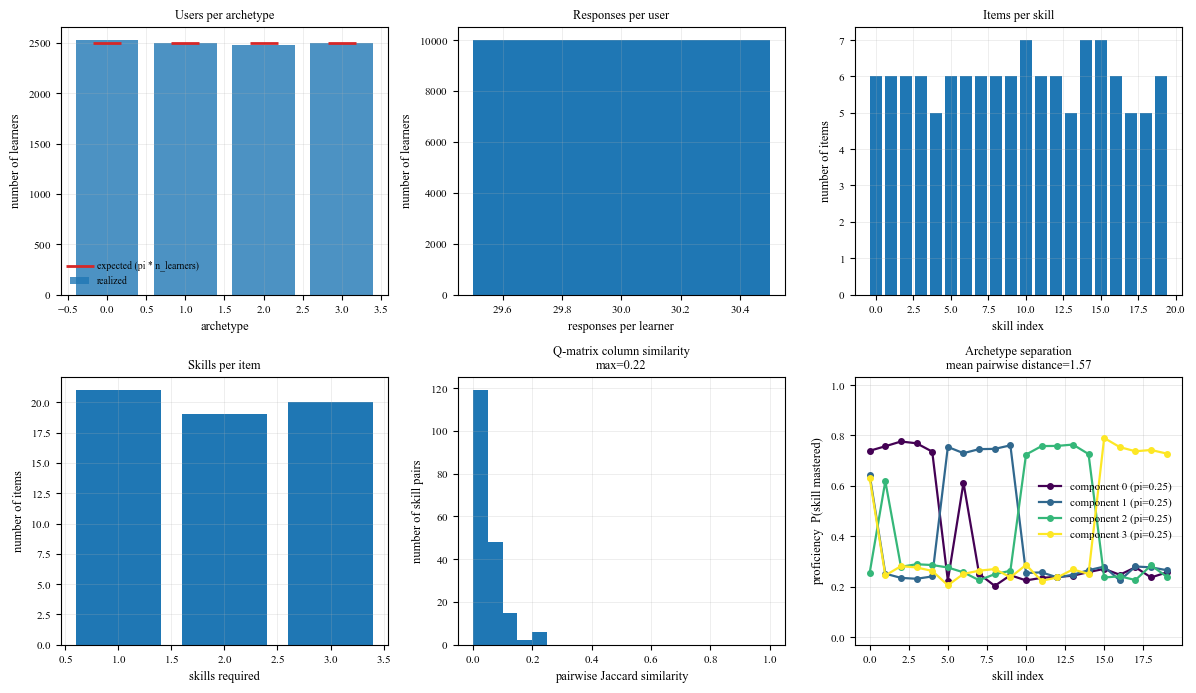

In [4]:
from src.simulations.factors import SimulationCondition
from src.simulations.dgp import generate_dataset
from src.simulations.viz import plot_setup_diagnostics

setup_data = generate_dataset(SimulationCondition(n_archetypes=4, n_learners=10_000), seed=0)
fig = plot_setup_diagnostics(setup_data, save="figures/setup_diagnostics.pdf")

## 1. Archetype Recovery

Fit MoLA on one well-specified condition and compare the recovered archetype profiles to the ones that generated the data, after Hungarian alignment. Also check item-difficulty (`theta`) recovery -- items keep a fixed, unambiguous index (no label-switching issue like archetypes have), so `plot_theta_recovery` needs no alignment step.

{'mu_rmse': 0.13572026539532123, 'theta_rmse': 0.0791091532083391, 'assignment_ari': 0.466766486480871, 'holdout_auc': 0.7425236753690185}


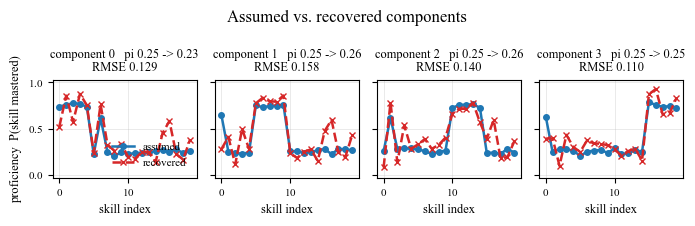

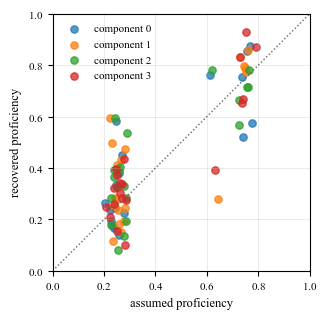

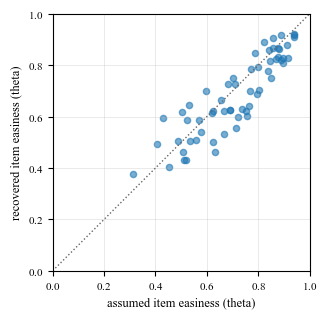

In [5]:
import matplotlib.pyplot as plt
from src.simulations import run_condition
from src.simulations.factors import SimulationCondition
from src.simulations.viz import plot_component_recovery, plot_recovery_scatter, plot_theta_recovery

result = run_condition(SimulationCondition(n_archetypes=4, n_learners=10_000), seed=0, return_fit=True)
plot_component_recovery(
    result, 
    figsize=figsize("acm-sigconf-text", aspect=0.32), 
    save="figures/component_recovery.pdf"
)

# plot_recovery_scatter / plot_theta_recovery have no figsize= of their own -- pass a pre-sized ax instead.
_, scatter_ax = plt.subplots(figsize=figsize("acm-sigconf-column", aspect=1.0))
plot_recovery_scatter(result, ax=scatter_ax, save="figures/recovery_scatter.pdf")

_, theta_ax = plt.subplots(figsize=figsize("acm-sigconf-column", aspect=1.0))
plot_theta_recovery(result, ax=theta_ax, save="figures/theta_recovery.pdf")

print({k: result.metrics[k] for k in ("mu_rmse", "theta_rmse", "assignment_ari", "holdout_auc")})

## 2. Estimation Stability

Fix one simulated dataset and its train/holdout split, then re-fit it many times, varying only the EM initialization draw (`run_init_repeats`). Every recovered archetype is aligned back to the true ones independently each time, then plotted together to show the spread across initializations -- tight bundles argue the solution doesn't depend on where EM started.

**A confound we found, fixed, and then checked wasn't the whole story.** The per-skill spread here does *not* come from whether a skill is an archetype's own distinguishing skill (checked directly -- no correlation). It did correlate strongly (r ≈ -0.63) with uneven Q-matrix item coverage across skills (`q_matrix`'s old fixed-probability draw made "balanced" coverage mean equal *probability* per skill, not equal *realized* count, leaving real sampling noise). `q_matrix` now self-balances coverage by construction (see Section 0) without needing to change `n_items` at all -- increasing `n_items` instead was tried and rejected: it dilutes responses *per item*, which measurably hurt `theta_rmse` and, past a point, made `mu_rmse` worse again too (`mu`/`theta` are jointly estimated).

That fix closed the confound (the coverage/instability correlation dropped to ≈0.13, essentially gone) but only reduced the overall spread by ~15% (mean per-skill std ~0.11-0.13 -> ~0.09-0.10) -- not a dramatic change, because coverage imbalance was never the whole story, just a real part of it. Checked several other candidates for the residual: distance of a skill's true mastery level from 0.5 (weak, r≈-0.12), the easiness of items covering a skill (moderate, r≈0.31, worth a follow-up but not dominant), and confirmed the ~0.09-0.11 level is stable across three independently-generated datasets (different `data_seed`s), not an artifact of one particular draw. The most defensible reading: this residual is genuine EM initialization sensitivity intrinsic to fitting a non-convex mixture likelihood, not a remaining data-design artifact -- MoLA's archetype recovery has an honest baseline sensitivity to where EM starts, on the order of ±0.10 in proficiency units, even under a well-designed assessment.

mean    0.145591
std     0.032993
min     0.081377
max     0.219458
dtype: float64

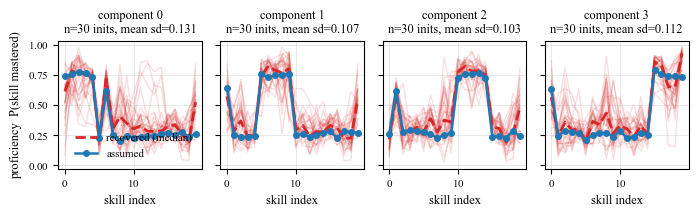

In [8]:
import pandas as pd
from src.simulations.factors import SimulationCondition
from src.simulations.run import run_init_repeats
from src.simulations.viz import plot_component_recovery_distribution

stability_condition = SimulationCondition(
    n_archetypes=4,
    n_learners=10_000,
    initialization="random",
    responses_per_learner=30,
)
stability_results = run_init_repeats(stability_condition, data_seed=0, n_repeats=30)
plot_component_recovery_distribution(
    stability_results,
    figsize=figsize("acm-sigconf-text", aspect=0.32),
    save="figures/stability.pdf",
)

mu_rmse_by_repeat = pd.Series([r.metrics["mu_rmse"] for r in stability_results])
mu_rmse_by_repeat.describe()[["mean", "std", "min", "max"]]

## 3. Robustness to Data Sparsity

One-factor-at-a-time sweep over the two evidence factors named in the claim -- number of users (`n_learners`) and number of item responses per user (`responses_per_learner`) -- holding everything else at baseline. `plot_ofat_sensitivity` takes the raw per-run table from `run_design` directly (not `summarize_results`'s aggregated output, which drops the per-condition factor columns this needs) and computes the mean/std per level itself.

A full OFAT grid at higher replication counts is many fits -- this starts small (`n_replications=5`, few levels); widen before using the figure for the final write-up.

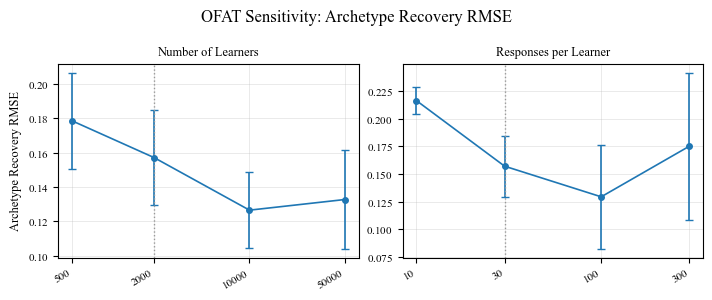

In [7]:
from src.simulations.factors import ofat_design
from src.simulations.run import run_design
from src.simulations.viz import plot_ofat_sensitivity

sparsity_factors = ["n_learners", "responses_per_learner"]
sparsity_conditions = ofat_design(factors=sparsity_factors)
sparsity_results = run_design(sparsity_conditions, n_replications=6, base_seed=0)

fig = plot_ofat_sensitivity(
    sparsity_results,
    factors=sparsity_factors,
    metric="mu_rmse",
    log_x=True,
    save="figures/sparsity.pdf",
)

**Do `n_learners` and `responses_per_learner` act through the same underlying quantity?** Both feed the same "effective observations per skill" product (`n_learners * responses_per_learner`), so `mu_rmse` should track that product regardless of the split -- but `assignment_ari` (individual cluster-assignment accuracy) depends on *per-learner* posterior precision specifically, so it shouldn't. Check with a couple of matched-product, different-split pairs.

In [8]:
from src.simulations.run import run_condition

iso_product_pairs = [
    ("many learners, few responses", dict(n_learners=8_000, responses_per_learner=15)),
    ("few learners, many responses", dict(n_learners=1_000, responses_per_learner=120)),
]
rows = []
for label, kw in iso_product_pairs:
    cond = SimulationCondition(n_archetypes=4, n_skills=20, initialization="random", **kw)
    m = run_condition(cond, seed=0)
    rows.append({"split": label, "n_learners * responses_per_learner": kw["n_learners"] * kw["responses_per_learner"],
                 "mu_rmse": m["mu_rmse"], "assignment_ari": m["assignment_ari"]})
pd.DataFrame(rows)

,split,n_learners * responses_per_learner,mu_rmse,assignment_ari
0,"many learners, few responses",120000,0.121661,0.207279
1,"few learners, many responses",120000,0.111485,0.947662


## 4. Sensitivity to the Number of Archetypes

Fit the SAME simulated data (`run_m_sweep` holds the data and train/holdout split fixed, since neither depends on `n_components_fit`) with a range of fitted archetype counts around the true one. `initialization="random"` is required here -- k-means/informed init assume the correct number of archetypes and `_initial_params` raises if they're combined with a misspecified `n_components_fit`.

`effective_n_archetypes()` -- the participation ratio of the fitted `mu` -- should saturate near the true count even once the model is handed more components than it needs, which is the payoff of the archetype-redundancy diagnostics built onto `MoLA` (`effective_n_archetypes`, `redundancy_report`).

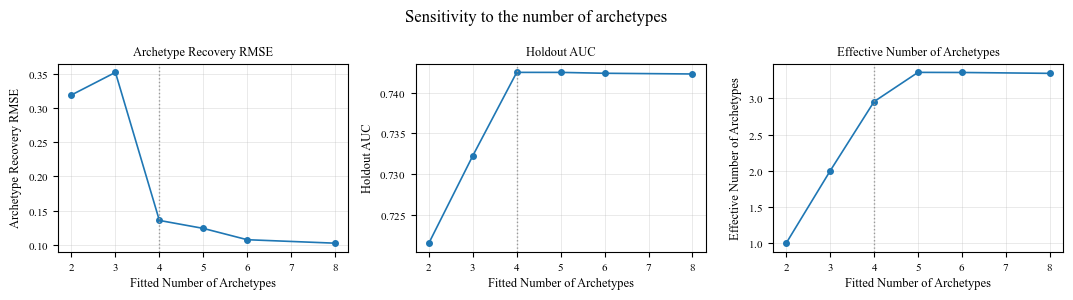

In [9]:
from src.simulations.factors import SimulationCondition
from src.simulations.run import run_m_sweep
from src.simulations.viz import plot_m_sensitivity

true_n_archetypes = 4
m_condition = SimulationCondition(n_archetypes=true_n_archetypes, n_learners=10_000)
m_results = run_m_sweep(m_condition, n_components_grid=[2, 3, 4, 5, 6, 8], seed=0)

fig = plot_m_sensitivity(
    m_results,
    true_n_archetypes=true_n_archetypes,
    metrics=("mu_rmse", "holdout_auc", "effective_n_archetypes"),
    save="figures/m_sensitivity.pdf",
)

## 5. Computational Scalability

Wall-clock fit time (`train_time_sec`, recorded by every `run_condition` call already) as problem size grows, using the same OFAT machinery as Section 3 but over the factors that plausibly drive compute cost: number of users, number of skills, and number of archetypes.

Plotted log-log (`log_x=True, log_y=True`): a power-law cost `time ~ n^p` is a straight line of slope `p` on log-log axes, so this is the honest way to read off the scaling exponent. Plotted with a linear time axis instead, genuinely linear cost (`p=1`) bends upward and can look quadratic or exponential -- a straight line under log-x/linear-y actually corresponds to *logarithmic* growth, not linear.

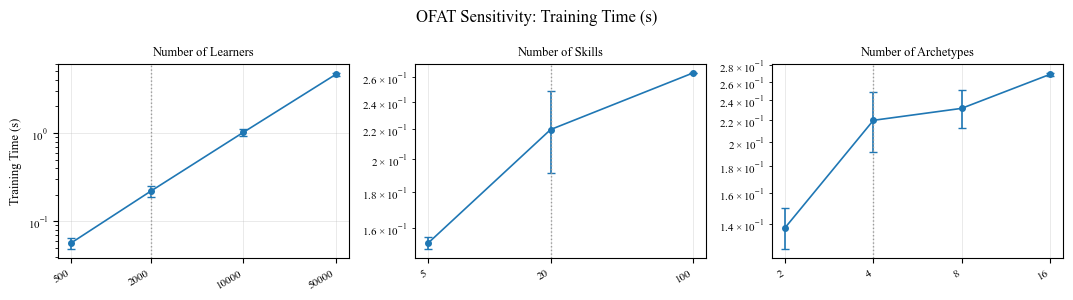

In [10]:
from src.simulations.factors import ofat_design
from src.simulations.run import run_design
from src.simulations.viz import plot_ofat_sensitivity

scalability_factors = ["n_learners", "n_skills", "n_archetypes"]
scalability_conditions = ofat_design(factors=scalability_factors)
scalability_results = run_design(scalability_conditions, n_replications=3, base_seed=0)

# log-log: a power law reads as a straight line whose slope is the exponent.
# (log_x alone, with a linear time axis, makes genuinely linear cost bend
# upward and look quadratic/exponential -- see the discussion above.)
fig = plot_ofat_sensitivity(
    scalability_results,
    factors=scalability_factors,
    metric="train_time_sec",
    log_x=True,
    log_y=True,
    save="figures/scalability.pdf",
)